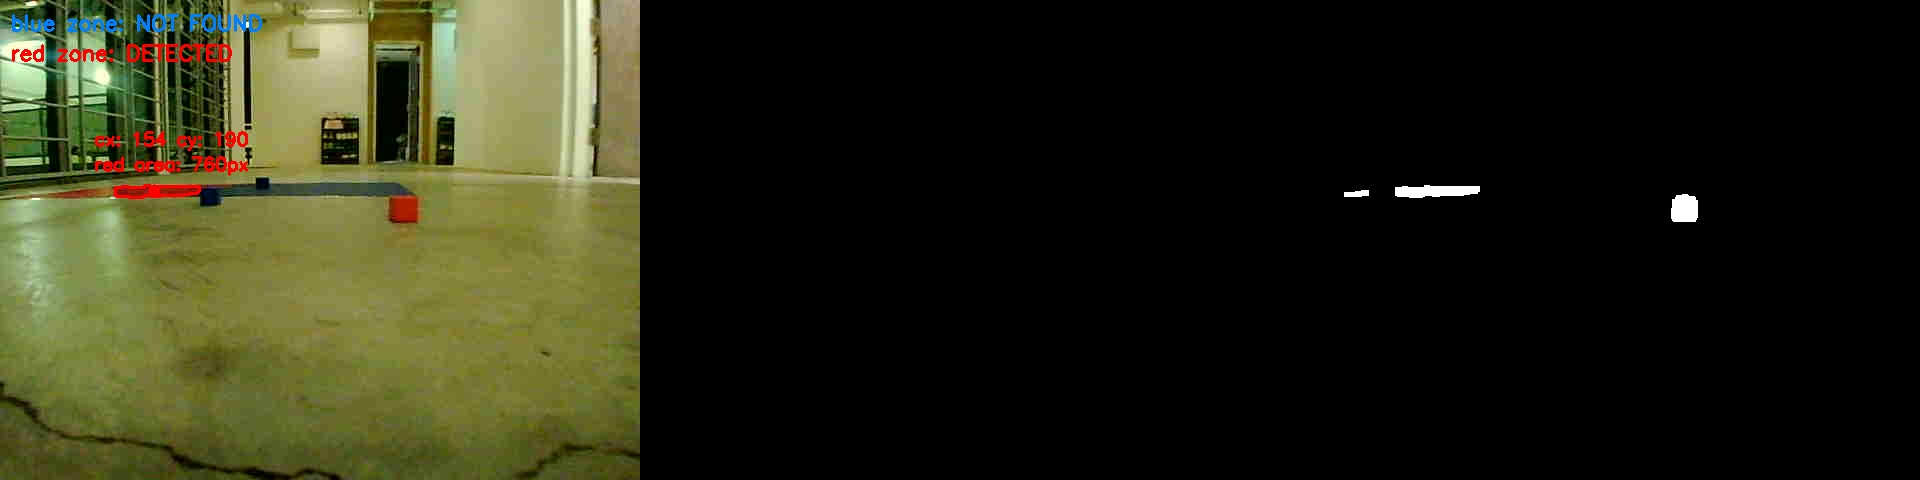

['Orange', 'Cube', 397.5, 202.5, 37, 41, 1517]
['Orange', 'Cube', 398.0, 202.0, 36, 40, 1440]
['Orange', 'Cube', 394.0, 202.0, 36, 38, 1368]
['Orange', 'Cube', 376.5, 203.5, 35, 39, 1365]
['Orange', 'Cube', 364.5, 203.0, 34, 37, 1258]
['Orange', 'Cube', 360.0, 202.5, 35, 38, 1330]
['Orange', 'Cube', 350.0, 200.0, 36, 36, 1296]
['Orange', 'Cube', 342.0, 202.0, 34, 38, 1292]
['Orange', 'Cube', 332.5, 202.0, 34, 37, 1258]
['Orange', 'Cube', 328.5, 202.5, 33, 37, 1221]
['Orange', 'Cube', 319.5, 202.5, 35, 37, 1295]
['Red', 'Cube', 308.0, 201.5, 33, 38, 1254]
['Orange', 'Cube', 303.5, 202.0, 32, 37, 1184]
['Orange', 'Cube', 294.0, 202.0, 32, 36, 1152]
['Orange', 'Cube', 286.0, 202.0, 32, 34, 1088]
['Orange', 'Cube', 278.0, 203.0, 32, 34, 1088]
['Orange', 'Cube', 279.0, 203.0, 34, 34, 1156]
['Orange', 'Ball', 262.5, 201.0, 34, 35, 1190]
['Orange', 'Cube', 258.5, 204.0, 32, 35, 1120]
['Orange', 'Cube', 246.0, 203.0, 34, 36, 1224]
['Orange', 'Cube', 241.0, 204.5, 33, 36, 1188]
['Orange', 'Cube

In [ ]:
scan_votes = {"Red": 0, "Blue": 0}

from ugot import ugot

# Create the robot controller object
got = ugot.UGOT()

# Connect to the robot — update this IP address if needed
got.initialize("192.168.137.162")

# Load the vision models required for this notebook
got.load_models(["color_recognition", "face_recognition"])

import cv2
import numpy as np
from IPython.display import display, Image, clear_output

got.open_camera()

BLUE_HSV_LOWER = np.array([ 90,  70,  40])
BLUE_HSV_UPPER = np.array([135, 255, 255])

# Red wraps around 0° in the hue circle, so two ranges are needed
RED_HSV_LOWER_1 = np.array([  0,  70,  70])  # low-hue red  (0–10°)
RED_HSV_UPPER_1 = np.array([ 10, 255, 255])
RED_HSV_LOWER_2 = np.array([170,  70,  70])  # high-hue red (170–180°)
RED_HSV_UPPER_2 = np.array([180, 255, 255])

# Minimum contour area in pixels — filters out small noise blobs
MIN_CONTOUR_AREA = 300

FRAME_W, FRAME_H = 640, 480  # Expected camera resolution
CENTER_TOLERANCE = 20  # Pixel dead-zone: errors smaller than this are ignored

# Bounding-box area (px²) at which the robot considers itself close enough to pick up
CLOSE_AREA_THRESHOLD = {
    "Red": 18000,
    "Blue": 18000,
}

# Deposit zone contour area (px²) at which the robot considers itself close enough to deposit
DEPOSIT_AREA_THRESHOLD = 70000

# Cubes with cy below this value are near the top of frame and are ignored
# (they are likely already deposited or at an unusable distance)
CUBE_SEARCH_THRESHOLD = 200
MAX_JUMP_PX = 100

# Total number of cubes to sort before stopping (not yet enforced in loop below)
NUMBER_OF_CUBES = 5

# --- Deposit zone HSV ranges (same as Deposit Check cell) ---
BLUE_HSV_LOWER = np.array([90, 70, 40])
BLUE_HSV_UPPER = np.array([135, 255, 255])
RED_HSV_LOWER_1 = np.array([0, 70, 70])
RED_HSV_UPPER_1 = np.array([10, 255, 255])
RED_HSV_LOWER_2 = np.array([170, 70, 70])
RED_HSV_UPPER_2 = np.array([180, 255, 255])
MIN_DEPOSIT_CONTOUR_AREA = 500  # Minimum deposit zone area to be considered valid

state = "navigate"  # Current FSM state (see state diagram in the markdown above)
detected_color = None  # Colour of the cube currently being handled ("Red" or "Blue")
camera_color = None
locked_cube_position = None
cube_detected = False  # True once a valid cube has been spotted in the current cycle
scanning = False
scan_frames_left = 0
SCAN_DURATION = 15
scan_candidates = {}
cube_locked = False
paper_state = None
paper_state_count = 0
PAPER_CONFIRM_FRAMES = 5
locked_cx = None
locked_cy = None
locked_area = None

def detect_zone(img, color):
    """Return a cleaned binary mask for the given deposit zone colour.

    Args:
        img:   BGR image from the camera.
        color: "blue" or "red".

    Returns:
        A single-channel binary mask (same H×W as img).
    """
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    if color == "blue":
        mask = cv2.inRange(hsv, BLUE_HSV_LOWER, BLUE_HSV_UPPER)
    elif color == "red":
        # Combine the two red ranges with a bitwise OR
        mask1 = cv2.inRange(hsv, RED_HSV_LOWER_1, RED_HSV_UPPER_1)
        mask2 = cv2.inRange(hsv, RED_HSV_LOWER_2, RED_HSV_UPPER_2)
        mask = cv2.bitwise_or(mask1, mask2)

    # Morphological opening: erode removes small noise, dilate restores large shapes
    mask = cv2.erode(mask, None, iterations=2)
    mask = cv2.dilate(mask, None, iterations=2)
    return mask

def detect_deposit_zone(img, zone_color):
    """Find the largest deposit zone region matching zone_color in img.

    Args:
        img:        BGR image from the camera.
        zone_color: "blue" or "red".

    Returns:
        (cx, cy, area) of the largest matching region, or None if not found.
    """
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    if zone_color == "blue":
        mask = cv2.inRange(hsv, BLUE_HSV_LOWER, BLUE_HSV_UPPER)
    elif zone_color == "red":
        # Combine both red hue ranges
        mask1 = cv2.inRange(hsv, RED_HSV_LOWER_1, RED_HSV_UPPER_1)
        mask2 = cv2.inRange(hsv, RED_HSV_LOWER_2, RED_HSV_UPPER_2)
        mask = cv2.bitwise_or(mask1, mask2)
    else:
        return None

    # Morphological opening to remove noise
    mask = cv2.erode(mask, None, iterations=2)
    mask = cv2.dilate(mask, None, iterations=2)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)
    if area < MIN_DEPOSIT_CONTOUR_AREA:
        return None  # Too small — likely noise

    # Compute centroid via image moments
    M = cv2.moments(largest)
    if M["m00"] == 0:
        return None
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    return cx, cy, area



def get_target_deposit(detected_color):

    if detected_color == "Red":
        return "red"

    if detected_color == "Blue":
        return "blue"

    return None

try:
    got.mecanum_translate_speed_times(angle=0, speed=30, times=70, unit=1)
    for x in range(5):
        # Read the latest raw JPEG frame from the robot camera
        frame = got.read_camera_data()

        # Decode: raw bytes → 1-D NumPy array → BGR colour image
        nparr = np.frombuffer(frame, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        # Query the colour recognition model.
        # Returns a tuple: (color, shape, center_x, center_y, height, width, area)
        # Returns an empty/falsy value if nothing is detected.
        result = got.get_color_total_info()

        if result and not cube_locked:
            color, shape, cx, cy, h, w, area = result

            # Cast coordinates to int — the model may return floats
            cx, cy = int(cx), int(cy)
            half_w, half_h = int(w / 2), int(h / 2)

            # Compute bounding box corners from centre + half-dimensions
            x1, y1 = cx - half_w, cy - half_h  # top-left
            x2, y2 = cx + half_w, cy + half_h  # bottom-right

            # Draw green bounding box and red centre dot
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.circle(img, (cx, cy), 4, (0, 0, 255), -1)

            # Build a two-line label: colour/shape/area on line 1, pixel position on line 2
            lines = [
                f"{color} {shape} area: {area}px",
                f"cx: {cx} cy: {cy}"
            ]

            # Draw lines above the bounding box, from bottom to top so line 1 is highest
            line_height = 25
            for i, line in enumerate(lines):
                y = (y1 - 10) - (len(lines) - 1 - i) * line_height
                cv2.putText(img, line, (x1, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        # Encode annotated frame and update the notebook display
        _, jpeg = cv2.imencode(".jpg", img)
        clear_output(wait=True)
        display(Image(data=jpeg.tobytes()))

        frame = got.read_camera_data()
        nparr = np.frombuffer(frame, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        results = {}  # stores (cx, cy, area) for each detected zone, or None
        masks   = {}  # stores the binary mask for each colour (used in the side-by-side display)

        # Process both deposit zone colours in one loop
        for color, draw_color in [("blue", (255, 128, 0)), ("red", (0, 0, 255))]:
            mask = detect_zone(img, color)
            masks[color] = mask

            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            results[color] = None

            if contours:
                # Work with only the largest region (ignore smaller spurious blobs)
                largest = max(contours, key=cv2.contourArea)
                area = cv2.contourArea(largest)

                if area > MIN_CONTOUR_AREA:
                    # Compute the contour's centroid using image moments
                    # m00 = total white-pixel count; m10/m01 = weighted x/y sums
                    M = cv2.moments(largest)
                    if M["m00"] != 0:
                        dcx = int(M["m10"] / M["m00"])  # centroid x
                        dcy = int(M["m01"] / M["m00"])  # centroid y
                        results[color] = (dcx, dcy, int(area))

                        # Annotate the live frame
                        cv2.drawContours(img, [largest], -1, draw_color, 2)
                        cv2.circle(img, (dcx, dcy), 6, draw_color, -1)
                        cv2.putText(img, f"{color} area: {int(area)}px", (dcx - 60, dcy - 20),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, draw_color, 2)
                        cv2.putText(img, f"cx: {dcx} cy: {dcy}", (dcx - 60, dcy - 45),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, draw_color, 2)

        # Print DETECTED / NOT FOUND status for each zone in the corner
        for i, (color, draw_color) in enumerate([("blue", (255, 128, 0)), ("red", (0, 0, 255))]):
            status = "DETECTED" if results[color] is not None else "NOT FOUND"
            cv2.putText(img, f"{color} zone: {status}", (10, 30 + i * 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, draw_color, 2)

        # Build a three-panel display: annotated camera | blue mask | red mask
        # Convert single-channel masks to BGR so they can be hstacked with the colour image
        blue_bgr = cv2.cvtColor(masks["blue"], cv2.COLOR_GRAY2BGR)
        red_bgr  = cv2.cvtColor(masks["red"],  cv2.COLOR_GRAY2BGR)
        combined = np.hstack([img, blue_bgr, red_bgr])

        _, jpeg = cv2.imencode(".jpg", combined)
        clear_output(wait=True)
        display(Image(data=jpeg.tobytes()))

        while True:
            # --- Grab and decode frame ---
            frame = got.read_camera_data()
            nparr = np.frombuffer(frame, np.uint8)
            img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

            # --- Deposit zone detection (runs every frame, used in multiple states) ---
            # Determine which zone colour to look for based on the cube currently held
            target_zone = get_target_deposit(detected_color)

            red_deposit = detect_deposit_zone(img, "red")
            blue_deposit = detect_deposit_zone(img, "blue")

            if red_deposit and blue_deposit:
                current_paper_state = "both"
            elif red_deposit:
                current_paper_state = "red"
            elif blue_deposit:
                current_paper_state = "blue"
            else:
                current_paper_state = None

            if current_paper_state == paper_state:
                paper_state_count += 1
            else:
                paper_state = current_paper_state
                paper_state_count += 1

            deposit = red_deposit if target_zone == "red" else blue_deposit

            # Overlay the deposit zone marker if one is found
            if deposit:
                dcx, dcy, darea = deposit
                dot_color = (0, 0, 255) if target_zone == "red" else (255, 128, 0)
                cv2.circle(img, (dcx, dcy), 6, dot_color, -1)
                cv2.putText(
                    img,
                    f"{target_zone} deposit area: {darea}px",
                    (dcx - 60, dcy - 15),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    dot_color,
                    2,
                )

            # ================================================================
            # FSM — one state is executed per frame
            # ================================================================
            cx = locked_cx
            cy = locked_cy
            area = locked_area
            if state == "navigate":
                result = got.get_color_total_info()
                print(result)

                if result and result[0] in ("Red", "Blue"):
                    camera_color, shape, cx, cy, h, w, area = result
                    scan_votes[camera_color] += 1
                    if camera_color not in ("Red", "Blue"):
                        camera_color = None
                    cx, cy = int(cx), int(cy)
                    # ...(drawing code unchanged)...

                    if cy > CUBE_SEARCH_THRESHOLD and not cube_detected:
                        # Start (or continue) a short scan instead of locking instantly
                        # Start quick scan
                        if not scanning and not cube_locked:
                            scanning = True
                            scan_frames_left = SCAN_DURATION
                            scan_candidates = {}
                            scan_votes = {"Red": 0, "Blue": 0}


                        # Save only the strongest detection
                        if not cube_locked:

                            previous = scan_candidates.get(camera_color)

                            if previous is None or area > previous[2]:
                                scan_candidates[camera_color] = (
                                    cx,
                                    cy,
                                    area
                                )


                        if scanning:

                            scan_frames_left -= 1

                            if scan_frames_left <= 0:

                                if scan_candidates:

                                    # Pick the largest cube, regardless of colour
                                    if scan_votes["Red"] > scan_votes["Blue"]:
                                        chosen_color = "Red"
                                    elif scan_votes["Blue"] > scan_votes["Red"]:
                                        chosen_color = "Blue"
                                    else:
                                        chosen_color = max(scan_candidates,
                                                        key=lambda c: scan_candidates[c][2])

                                    detected_color = str(chosen_color)

                                    cx, cy, area = scan_candidates[chosen_color]

                                    locked_cube_position = (cx, cy)

                                    cube_detected = True
                                    cube_locked = True
                                    locked_cx, locked_cy, locked_area = cx, cy, area


                                scanning = False
                                scan_candidates = {}
                                scan_votes = {"Red": 0, "Blue": 0}
                        # Keep only the closest (largest-area) sighting per colour during the scan
                        prev = scan_candidates.get(color)
                        if prev is None or area > prev[2]:
                            scan_candidates[camera_color] = (cx, cy, area)

                if cube_detected:
                    # Only accept a new reading as "our" cube if it's (a) the right colour
                    # and (b) close to where we last saw it. A same-coloured detection that
                    # jumps far away is almost certainly a *different* cube of the same
                    # colour (e.g. one of the other 2 red blocks) — ignore it and keep
                    # coasting on the last known position instead of chasing it.
                    if result and cube_locked:

                        current_camera_color = result[0]
                        if current_camera_color not in ("Red", "Blue"):
                            current_camera_color = None

                        # Only update position, never update colour
                        if result and result[2] != -1:

                            new_cx = int(result[2])
                            new_cy = int(result[3])

                            dist = (
                                (new_cx - locked_cx)**2 +
                                (new_cy - locked_cy)**2
                            ) ** 0.5

                            if dist < MAX_JUMP_PX:
                                locked_cx, locked_cy = new_cx, new_cy
                                locked_area = result[6]
                        cx = locked_cx
                        cy = locked_cy
                        area = locked_area
                        # else: reported cube is too far from last position — likely a
                        # different physical cube, ignore this frame's reading

                    frame_cx = FRAME_W // 2
                    x_error = cx - frame_cx
                    threshold = CLOSE_AREA_THRESHOLD.get(detected_color, 70000)


                    if area >= threshold:
                        print("ARRIVED CONDITION HIT")
                        got.mecanum_stop()
                        nav_status = "Arrived!"
                        state = "arrived"
                    elif abs(x_error) > CENTER_TOLERANCE:
                        got.mecanum_move_xyz(-10 if x_error < 0 else 10, 5, 0)
                        nav_status = f"Centering on {detected_color}: x_error={x_error}px"
                    else:
                        got.mecanum_move_xyz(0, 10, 0)
                        nav_status = f"Approaching {detected_color}: area={area}px"
                elif not scanning and not cube_locked:

                    if paper_state_count >= PAPER_CONFIRM_FRAMES:
                            if paper_state == "blue":
                                got.mecanum_move_xyz(-15, 0, 0)
                                nav_status = "Searching left side..."
                            elif paper_state == "red":
                                got.mecanum_move_xyz(15, 0, 0)
                                nav_status = "Searching right side"
                            else:
                                got.mecanum_move_xyz(10, 0, 0)
                                nav_status = "Searching..."

                    else:
                        got.mecanum_move_xyz(10, 0, 0)
                        nav_status = "Searching..."
            elif state == "arrived":
                # Drive forward a fixed amount to position alongside the cube for pick-up
                # times=35 at speed 20 approximates a fixed distance nudge
                got.mecanum_move_speed_times(0, 20, 35, 1)
                cv2.putText(
                    img,
                    f"Arrived - handling {detected_color} cube",
                    (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (0, 255, 255),
                    2,
                )
                state = "find_deposit"  # Immediately advance — the nudge is blocking

            elif state == "find_deposit":
                # Check if the deposit zone is already visible in the current frame
                if deposit:
                    got.mecanum_stop()
                    state = "approach_deposit"
                    nav_status = f"Found {target_zone} deposit zone!"
                else:
                    if detected_color == "Red":
                        if blue_deposit:
                            got.mecanum_move_xyz(-15, 0, 0)  # Strafe left to find red zone
                            nav_status = "Searching for red deposit zone..."
                    elif detected_color == "Blue":
                        if red_deposit:
                            got.mecanum_move_xyz(15, 0, 0)  # Strafe right to find blue zone
                            nav_status = "Searching for blue deposit zone..."

                cv2.putText(
                    img,
                    nav_status,
                    (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (255, 100, 0),
                    2,
                )

            elif state == "approach_deposit":
                if deposit:
                    dcx, dcy, darea = deposit
                    frame_cx = FRAME_W // 2
                    x_error = dcx - frame_cx  # Positive = zone is to the right

                    if abs(x_error) > CENTER_TOLERANCE:
                        # Zone is off-centre — strafe to align while creeping forward
                        got.mecanum_move_xyz(-15 if x_error < 0 else 15, 10, 0)
                        nav_status = f"Centering on deposit: x_error={x_error}px"
                    elif darea < DEPOSIT_AREA_THRESHOLD:
                        # Zone is centred but still small (far) — drive straight toward it
                        got.mecanum_move_xyz(0, 15, 0)
                        nav_status = f"Approaching deposit: area={darea}px (target: {DEPOSIT_AREA_THRESHOLD}px)"
                    else:
                        # Zone is centred AND large enough — stop and deposit
                        got.mecanum_stop()
                        nav_status = "At deposit zone!"
                        state = "deposit"
                else:
                    # Lost sight of the zone mid-approach — back off and search again
                    got.mecanum_stop()
                    nav_status = "Deposit zone lost, searching..."
                    state = "find_deposit"
                    got.mecanum_turn_speed(turn=2, speed=20)

                cv2.putText(
                    img,
                    nav_status,
                    (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (255, 100, 0),
                    2,
                )

            elif state == "deposit":
                # Deposit sequence:
                # 1. Nudge forward to push the cube into the zone
                # 2. Reverse away from the zone
                # 3. Spin 180° to face back toward the cube field
                cv2.putText(
                    img,
                    "Depositing!",
                    (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (0, 255, 255),
                    2,
                )

                got.mecanum_move_speed_times(0, 20, 10, 1)  # Forward nudge
                got.mecanum_move_speed_times(1, 30, 40, 1)  # Reverse away
                got.mecanum_turn_speed_times(2, 200, 180, 2)  # Turn 180°
                

                state = "back_to_home"

            elif state == "back_to_home":
                            result = got.get_color_total_info()
                            cv2.putText(
                                img,
                                "Returning to home",
                                (10, 30),
                                cv2.FONT_HERSHEY_SIMPLEX,
                                0.7,
                                (0, 255, 255),
                                2,
                            )

                            # Check whether another cube is blocking the path home.
                            # An empty result comes back as ('',) or (False,) when nothing is detected.
                            if result[0] == "" or result == (False,):
                                print('asik')
                            
                                got.mecanum_move_speed_times(
                                    0, 20, 50, 1
                                )  # Drive forward (toward cube field)
                                got.mecanum_stop()
                                got.mecanum_turn_speed_times(2, 200, 180, 2)  # Turn 180°
                                state = "navigate"
                                cube_detected = False  # Reset flag so a new cube can be detected
                                cube_locked = False
                                detected_color = None  # Reset so a new cube can be detected
                                locked_cube_position = None
                                scanning = False
                                scan_candidates = {}
                                scan_votes = {"Red": 0, "Blue": 0}
                                break  # Cycle complete — exit inner loop so outer loop moves to next cube
                            else:
                                # A cube is in the way — strafe to avoid it, then re-check next frame.
                                # Stay in "back_to_home" and keep looping instead of breaking blind.
                                got.mecanum_move_xyz(20, 0, 0)


except KeyboardInterrupt:
    print("Done")
    print(state)
    got.mecanum_stop()